In [1]:
import pandas as pd
import numpy as np

import warnings

warnings.filterwarnings('ignore')

# Iterate over pandas dataframe best 3 techniques out of 5

In [2]:
 data= {
    "name": ["John Doe", "Alice Smith", "Bob Johnson", "David Lee", "Emma Clark", 
             "Sophia Adams", "James White", "Mia Brown", "Oliver Scott", 
             "Charlotte Young", "Liam Miller", "Amelia Wilson"],
    "age": [28, 34, 45, 29, 31, 40, 50, 22, 38, 33, 42, 26],
    "salary": [60000, 75000, 90000, 68000, 72000, 85000, 100000, 45000, 88000, 67000, 95000, 48000],
    "job": ["Engineer", "Data Scientist", "Manager", "Software Developer", 
            "Accountant", "HR Specialist", "Director", "Intern", 
            "Consultant", "Marketing Specialist", "CEO", "Analyst"]
}


In [3]:
df=pd.DataFrame(data)
df.head()

,name,age,salary,job
0,John Doe,28,60000,Engineer
1,Alice Smith,34,75000,Data Scientist
2,Bob Johnson,45,90000,Manager
3,David Lee,29,68000,Software Developer
4,Emma Clark,31,72000,Accountant


In [4]:
# df.apply(lambda x:print(x),axis=1) apply iterate over dataframe row wise and it much efficient 

In [5]:
df['First Name']=df.apply(lambda x: x['name'].split(' ')[0],axis=1)
df['Last Name']=df.apply(lambda x: x['name'].split(' ')[-1],axis=1)

In [6]:
df.head()

,name,age,salary,job,First Name,Last Name
0,John Doe,28,60000,Engineer,John,Doe
1,Alice Smith,34,75000,Data Scientist,Alice,Smith
2,Bob Johnson,45,90000,Manager,Bob,Johnson
3,David Lee,29,68000,Software Developer,David,Lee
4,Emma Clark,31,72000,Accountant,Emma,Clark


In [7]:
#  df.iterrows() it iterates over the dataframe row wise

In [8]:
for _,row in df.iterrows():
    print(row['name'],row['age'])

John Doe 28
Alice Smith 34
Bob Johnson 45
David Lee 29
Emma Clark 31
Sophia Adams 40
James White 50
Mia Brown 22
Oliver Scott 38
Charlotte Young 33
Liam Miller 42
Amelia Wilson 26


In [9]:
# df.itertuples() it returns named Tuple and we can used it to iterate over the dataframe

In [10]:
for row in df.itertuples():
    df.loc[row.Index,'Double Age']=row.age * 2

In [11]:
df.head()

,name,age,salary,job,First Name,Last Name,Double Age
0,John Doe,28,60000,Engineer,John,Doe,56.0
1,Alice Smith,34,75000,Data Scientist,Alice,Smith,68.0
2,Bob Johnson,45,90000,Manager,Bob,Johnson,90.0
3,David Lee,29,68000,Software Developer,David,Lee,58.0
4,Emma Clark,31,72000,Accountant,Emma,Clark,62.0


# pandas.replace method

In [12]:
new_data={
    'X':[1,2,3,4,5],
    'Y':[5,6,7,8,9],
    'Z':['z','y','x','w','v']
}
df=pd.DataFrame(new_data)
df.head()

,X,Y,Z
0,1,5,z
1,2,6,y
2,3,7,x
3,4,8,w
4,5,9,v


In [13]:
df.replace(to_replace=2,value=20)

,X,Y,Z
0,1,5,z
1,20,6,y
2,3,7,x
3,4,8,w
4,5,9,v


In [14]:
df.replace(to_replace=[1,2,3],value=20)

,X,Y,Z
0,20,5,z
1,20,6,y
2,20,7,x
3,4,8,w
4,5,9,v


In [15]:
df.replace(to_replace=[1,2,3],value=[10,20,30])

,X,Y,Z
0,10,5,z
1,20,6,y
2,30,7,x
3,4,8,w
4,5,9,v


In [16]:
df.replace(to_replace={1:10,2:20,'z':'zz'})

,X,Y,Z
0,10,5,zz
1,20,6,y
2,3,7,x
3,4,8,w
4,5,9,v


In [17]:
df.replace({'X':{1:10,5:50}})

,X,Y,Z
0,10,5,z
1,2,6,y
2,3,7,x
3,4,8,w
4,50,9,v


In [18]:
df.replace([1,2,3],method='bfill')

,X,Y,Z
0,4,5,z
1,4,6,y
2,4,7,x
3,4,8,w
4,5,9,v


# pandas Get Dummies

In [19]:
new_data=[('Foreign Cinema',289.0),('Foreign Cinema',80.5),('Liho Liho',224.0),('500 Club',80.5),('Foreign Cinema',25.3)]

In [20]:
df=pd.DataFrame(new_data,columns=('name','Amount'))
df

,name,Amount
0,Foreign Cinema,289.0
1,Foreign Cinema,80.5
2,Liho Liho,224.0
3,500 Club,80.5
4,Foreign Cinema,25.3


In [21]:
pd.get_dummies(df,columns=['name'])

,Amount,name_500 Club,name_Foreign Cinema,name_Liho Liho
0,289.0,False,True,False
1,80.5,False,True,False
2,224.0,False,False,True
3,80.5,True,False,False
4,25.3,False,True,False


In [22]:
pd.get_dummies(df,columns=['name']).astype(int)

,Amount,name_500 Club,name_Foreign Cinema,name_Liho Liho
0,289,0,1,0
1,80,0,1,0
2,224,0,0,1
3,80,1,0,0
4,25,0,1,0


In [23]:
pd.get_dummies(df,columns=['name'],prefix='dmy').astype(int)

,Amount,dmy_500 Club,dmy_Foreign Cinema,dmy_Liho Liho
0,289,0,1,0
1,80,0,1,0
2,224,0,0,1
3,80,1,0,0
4,25,0,1,0


In [24]:
pd.get_dummies(df,columns=['name'],prefix='dmy',prefix_sep='*').astype(int)

,Amount,dmy*500 Club,dmy*Foreign Cinema,dmy*Liho Liho
0,289,0,1,0
1,80,0,1,0
2,224,0,0,1
3,80,1,0,0
4,25,0,1,0


In [25]:
pd.get_dummies(df,columns=['name'],drop_first=True).astype(int)

,Amount,name_Foreign Cinema,name_Liho Liho
0,289,1,0
1,80,1,0
2,224,0,1
3,80,0,0
4,25,1,0


In [26]:
x=df.to_numpy()
x

array([['Foreign Cinema', 289.0],
       ['Foreign Cinema', 80.5],
       ['Liho Liho', 224.0],
       ['500 Club', 80.5],
       ['Foreign Cinema', 25.3]], dtype=object)

In [27]:
x=df.to_numpy(na_value='NAN')
x

array([['Foreign Cinema', 289.0],
       ['Foreign Cinema', 80.5],
       ['Liho Liho', 224.0],
       ['500 Club', 80.5],
       ['Foreign Cinema', 25.3]], dtype=object)

In [28]:
np.random.seed(seed=42)

In [29]:
np.random.randint(10,200, size=(1,4))[0]

array([112, 189, 102,  24])

# PANDAS Query for data Filteration

In [30]:
df=pd.DataFrame.from_dict({
    'Name':['Liho Liho','Tompkins','The Square','Chambers'],
    "Mon":np.random.randint(10,200, size=(1,4))[0],
    "Tues":np.random.randint(12,200, size=(1,4))[0],
    "Wed":np.random.randint(10,200, size=(1,4))[0],
    "Thurs":np.random.randint(10,200, size=(1,4))[0]
})
df

,Name,Mon,Tues,Wed,Thurs
0,Liho Liho,116,114,126,140
1,Tompkins,81,133,109,159
2,The Square,198,86,113,62
3,Chambers,30,99,161,11


In [31]:
df.query("Mon>100")

,Name,Mon,Tues,Wed,Thurs
0,Liho Liho,116,114,126,140
2,The Square,198,86,113,62


In [32]:
df.query("Mon<Tues and  Tues>Wed")

,Name,Mon,Tues,Wed,Thurs
1,Tompkins,81,133,109,159


In [33]:
dinner_limit=85
# @ sign in the query shows that it is a variable
df.query("Mon< @dinner_limit")

,Name,Mon,Tues,Wed,Thurs
1,Tompkins,81,133,109,159
3,Chambers,30,99,161,11


# pandas pop 

In [34]:
new_data=[('Foreign Cinema','Restaurant',289.0),('Foreign Cinema','Restaurant',80.5),('Liho Liho','Restaurant',224.0),('500 Club','bar',80.5),('The Square','bar',25.3)]

In [35]:
df=pd.DataFrame(new_data,columns=('name','types','AvgBill'))

In [36]:
df

,name,types,AvgBill
0,Foreign Cinema,Restaurant,289.0
1,Foreign Cinema,Restaurant,80.5
2,Liho Liho,Restaurant,224.0
3,500 Club,bar,80.5
4,The Square,bar,25.3


In [37]:
x=df.pop('types')
x

0    Restaurant
1    Restaurant
2    Restaurant
3           bar
4           bar
Name: types, dtype: object

In [38]:
df

,name,AvgBill
0,Foreign Cinema,289.0
1,Foreign Cinema,80.5
2,Liho Liho,224.0
3,500 Club,80.5
4,The Square,25.3


<Axes: xlabel='name', ylabel='AvgBill'>

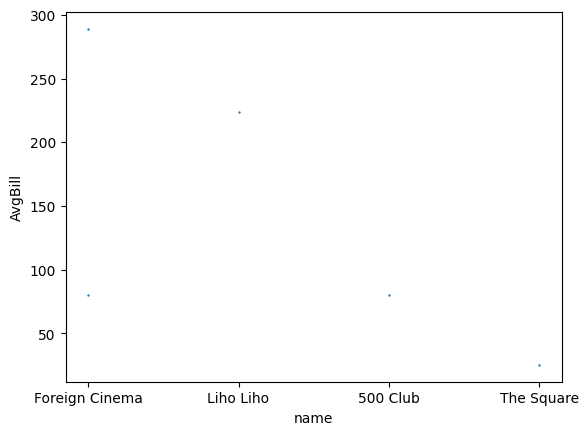

In [39]:
df.plot.scatter('name','AvgBill',s=0.5)

In [40]:
df['name'].value_counts()

name
Foreign Cinema    2
Liho Liho         1
500 Club          1
The Square        1
Name: count, dtype: int64

In [41]:
df['name'].value_counts(normalize=True)

name
Foreign Cinema    0.4
Liho Liho         0.2
500 Club          0.2
The Square        0.2
Name: proportion, dtype: float64

In [42]:
# bins divide the dataframe in specified number of groups and then check how many times the values appeared in that group
df['AvgBill'].value_counts(bins=3)

(25.035, 113.2]    3
(201.1, 289.0]     2
(113.2, 201.1]     0
Name: count, dtype: int64

In [43]:
# by providing the list of numbers in bins pandas will generate groups accordingly and provide values based on that
df['AvgBill'].value_counts(bins=[20,130,200,290])

(19.999, 130.0]    3
(200.0, 290.0]     2
(130.0, 200.0]     0
Name: count, dtype: int64

In [44]:
new_df=df.set_index('name')

In [45]:
new_df

,AvgBill
name,
Foreign Cinema,289.0
Foreign Cinema,80.5
Liho Liho,224.0
500 Club,80.5
The Square,25.3


In [46]:
new_df.loc[['Foreign Cinema']]

,AvgBill
name,
Foreign Cinema,289.0
Foreign Cinema,80.5


In [47]:
df.set_index(pd.Series(['FC','FC','L','500','TS']))

,name,AvgBill
FC,Foreign Cinema,289.0
FC,Foreign Cinema,80.5
L,Liho Liho,224.0
500,500 Club,80.5
TS,The Square,25.3


In [48]:
df.set_index(pd.Series(['FC','FC','L','500','TS']),append=True)

,,name,AvgBill
0,FC,Foreign Cinema,289.0
1,FC,Foreign Cinema,80.5
2,L,Liho Liho,224.0
3,500,500 Club,80.5
4,TS,The Square,25.3


In [49]:
np.random.seed(seed=42)
df=pd.DataFrame(data=np.random.randint(0,100,(4,3)),
               columns=('Test1','Test2','Test3'),
                index=('Bob','Sally','Frank','Patty')
               )
df

,Test1,Test2,Test3
Bob,51,92,14
Sally,71,60,20
Frank,82,86,74
Patty,74,87,99


In [50]:
df.idxmax(axis=1)

Bob      Test2
Sally    Test1
Frank    Test2
Patty    Test3
dtype: object

In [51]:
df.idxmax(axis=0)

Test1    Frank
Test2      Bob
Test3    Patty
dtype: object

In [52]:
df.idxmin(axis=1)

Bob      Test3
Sally    Test3
Frank    Test3
Patty    Test1
dtype: object

# Pandas Resample

In [56]:
index = pd.date_range('2/1/2020', periods=9, freq='T')
df = pd.DataFrame(data=range(9), index=index,columns=['count'])
df

,count
2020-02-01 00:00:00,0
2020-02-01 00:01:00,1
2020-02-01 00:02:00,2
2020-02-01 00:03:00,3
2020-02-01 00:04:00,4
2020-02-01 00:05:00,5
2020-02-01 00:06:00,6
2020-02-01 00:07:00,7
2020-02-01 00:08:00,8


In [63]:
df.resample('5T').sum()

,count
2020-02-01 00:00:00,10
2020-02-01 00:05:00,26


# pandas melt

In [64]:
df=pd.DataFrame.from_dict({
    "Name":['Liho Liho','Trompkins','The Squeare','Chambers'],
    '8/4/2020':np.random.randint(10,200,size=(1,4))[0],
    '8/5/2020':np.random.randint(10,200,size=(1,4))[0],
    '8/6/2020':np.random.randint(10,200,size=(1,4))[0],
    '8/7/2020':np.random.randint(10,200,size=(1,4))[0]
},orient='columns')

In [65]:
df

,Name,8/4/2020,8/5/2020,8/6/2020,8/7/2020
0,Liho Liho,181,90,141,115
1,Trompkins,17,173,11,13
2,The Squeare,184,59,143,63
3,Chambers,44,113,63,155


In [72]:
# id_vars is the list/string used to split our dataframe on that list
df.melt(id_vars='Name',var_name="Date",value_name='Ratings')

,Name,Date,Ratings
0,Liho Liho,8/4/2020,181
1,Trompkins,8/4/2020,17
2,The Squeare,8/4/2020,184
3,Chambers,8/4/2020,44
4,Liho Liho,8/5/2020,90
5,Trompkins,8/5/2020,173
6,The Squeare,8/5/2020,59
7,Chambers,8/5/2020,113
8,Liho Liho,8/6/2020,141
9,Trompkins,8/6/2020,11


In [69]:
# value_vars list used to get specific data for specific columns
df.melt(id_vars='Name',var_name="Date",value_name='Ratings',value_vars=['8/4/2020'])

,Name,Date,Ratings
0,Liho Liho,8/4/2020,181
1,Trompkins,8/4/2020,17
2,The Squeare,8/4/2020,184
3,Chambers,8/4/2020,44


In [73]:
# value_vars list used to get specific data for specific columns
df.melt(id_vars=['Name','8/4/2020'],var_name="Date",value_name='Ratings')

,Name,8/4/2020,Date,Ratings
0,Liho Liho,181,8/5/2020,90
1,Trompkins,17,8/5/2020,173
2,The Squeare,184,8/5/2020,59
3,Chambers,44,8/5/2020,113
4,Liho Liho,181,8/6/2020,141
5,Trompkins,17,8/6/2020,11
6,The Squeare,184,8/6/2020,143
7,Chambers,44,8/6/2020,63
8,Liho Liho,181,8/7/2020,115
9,Trompkins,17,8/7/2020,13


In [74]:
df

,Name,8/4/2020,8/5/2020,8/6/2020,8/7/2020
0,Liho Liho,181,90,141,115
1,Trompkins,17,173,11,13
2,The Squeare,184,59,143,63
3,Chambers,44,113,63,155


In [82]:
# convert dataframe to list

In [81]:
df.to_numpy().tolist()

[['Liho Liho', 181, 90, 141, 115],
 ['Trompkins', 17, 173, 11, 13],
 ['The Squeare', 184, 59, 143, 63],
 ['Chambers', 44, 113, 63, 155]]

In [83]:
df['Name'].tolist()

['Liho Liho', 'Trompkins', 'The Squeare', 'Chambers']

# pandas histogram

In [89]:
np.random.seed(42)  # for reproducible results

data = {
    'Age': np.random.randint(18, 60, size=100),
    'Salary': np.random.randint(30000, 100000, size=100),
    'Experience': np.random.randint(1, 30, size=100)
}
df = pd.DataFrame(data)
df.head()

,Age,Salary,Experience
0,56,38392,10
1,46,60535,3
2,32,82256,7
3,25,65222,28
4,38,93335,16


array([[<Axes: title={'center': 'Salary'}>,
        <Axes: title={'center': 'Age'}>]], dtype=object)

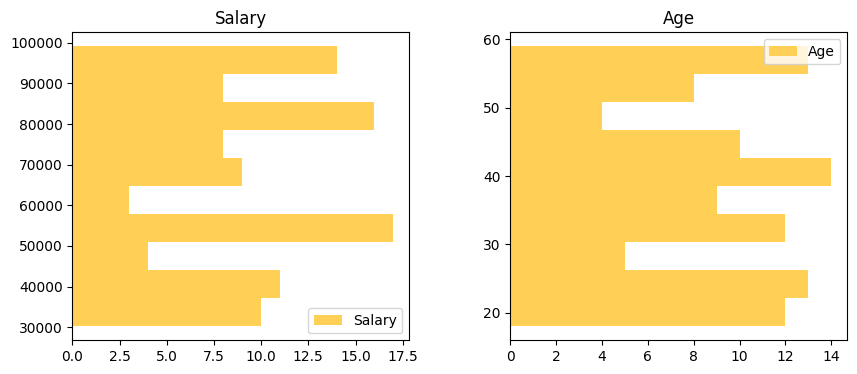

In [102]:
# df.hist(['Salary','Age'],bins=2)
df.hist(['Salary','Age'],grid=False,figsize=(10,4),legend=True,orientation='horizontal',color='#FFCF56')

array([[<Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>]], dtype=object)

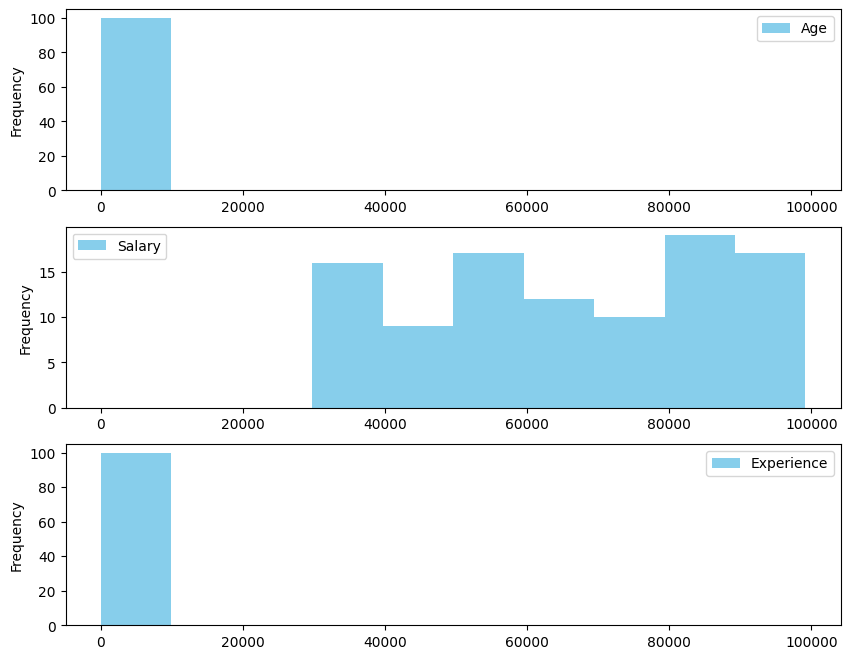

In [105]:
df.plot(kind='hist', subplots=True, bins=10, figsize=(10, 8), layout=(3, 1), sharex=False, color=['skyblue'])


In [116]:
df = pd.DataFrame([(234.0, 289.0),
                   (135.0, 224.0),
                   (23.0, 80.5),
                   (53.0, 25.30)],
           columns=('AvgBill1', 'AvgBill2')
                 )
df

,AvgBill1,AvgBill2
0,234.0,289.0
1,135.0,224.0
2,23.0,80.5
3,53.0,25.3


In [110]:
df.sum(axis=0)

AvgBill1    445.0
AvgBill2    618.8
dtype: float64

In [109]:
df.sum(axis=1)

0    523.0
1    359.0
2    103.5
3     78.3
dtype: float64

In [117]:
df['AvgBill1'].sum()

445.0

In [113]:
data = (['Apple','Red',3,1.29],
        ['Apple','Green',9,0.99],
        ['Pear','Red',25,2.59],
        ['Pear','Green',26,2.79],
        ['Lime','Green',99,0.39])
df = pd.DataFrame(data, columns=['Fruit','Color','Count','Price'])
df = df.set_index(['Fruit', 'Color'])
df

Count  Price
Fruit Color              
Apple Red        3   1.29
      Green      9   0.99
Pear  Red       25   2.59
      Green     26   2.79
Lime  Green     99   0.39

# pandas Sample

In [118]:
df = pd.DataFrame([('Foreign Cinema', 'Restaurant', 289.0),
                   ('Liho Liho', 'Restaurant', 224.0),
                   ('500 Club', 'bar', 80.5),
                   ('The Square', 'bar', 25.30),
                   ('Page', 'bar', 80.34),
                   ('Tompkins', 'bar', 34.2),
                   ('Als Place', 'Restaurant', 56.52),],
           columns=('name', 'type', 'AvgBill')
                 )
df

,name,type,AvgBill
0,Foreign Cinema,Restaurant,289.00
1,Liho Liho,Restaurant,224.00
2,500 Club,bar,80.50
3,The Square,bar,25.30
4,Page,bar,80.34
5,Tompkins,bar,34.20
6,Als Place,Restaurant,56.52


In [120]:
df.sample(2,ignore_index=True)

,name,type,AvgBill
0,Liho Liho,Restaurant,224.00
1,Als Place,Restaurant,56.52


In [122]:
df.sample(frac=.3,ignore_index=True)

,name,type,AvgBill
0,Liho Liho,Restaurant,224.0
1,Foreign Cinema,Restaurant,289.0


In [124]:
# by defualt pandas sample function only select a row once but if replace is True then it can repeat rows
df.sample(frac=.7,ignore_index=True,replace=True)

,name,type,AvgBill
0,Tompkins,bar,34.2
1,Liho Liho,Restaurant,224.0
2,500 Club,bar,80.5
3,Tompkins,bar,34.2
4,Liho Liho,Restaurant,224.0


In [125]:
weights = {'Restaurant': 5,
          'bar': 1}
df['weights'] = df['type'].apply(lambda x: weights[x])
df

,name,type,AvgBill,weights
0,Foreign Cinema,Restaurant,289.00,5
1,Liho Liho,Restaurant,224.00,5
2,500 Club,bar,80.50,1
3,The Square,bar,25.30,1
4,Page,bar,80.34,1
5,Tompkins,bar,34.20,1
6,Als Place,Restaurant,56.52,5


In [127]:
# higher weights and therefore a bigger chance to be picked.
df.sample(n=3, weights='weights', random_state=42)

,name,type,AvgBill,weights
1,Liho Liho,Restaurant,224.00,5
6,Als Place,Restaurant,56.52,5
5,Tompkins,bar,34.20,1


In [128]:
df.sample(2,axis=1)

,name,type
0,Foreign Cinema,Restaurant
1,Liho Liho,Restaurant
2,500 Club,bar
3,The Square,bar
4,Page,bar
5,Tompkins,bar
6,Als Place,Restaurant


# Pivot Table in Pandas

1. Pivot Table in Pandas
A pivot table is used to summarize data in a DataFrame by aggregating it according to specific columns (similar to Excel’s pivot table). It allows you to reshape data based on column and index values.

Key Features:
You can specify rows (index), columns, and values to summarize.
You can apply various aggregation functions (like sum(), mean(), count()).
You can group data by multiple levels of index and columns.

DataFrame.pivot_table(values, index, columns, aggfunc)

In [129]:
data = {
    'Department': ['Sales', 'Sales', 'HR', 'HR', 'IT', 'IT'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
    'Salary': [50000, 60000, 55000, 45000, 70000, 80000]
}
df = pd.DataFrame(data)

# Creating a pivot table that calculates the average salary per department
pivot_table = df.pivot_table(values='Salary', index='Department', aggfunc='mean')
pivot_table

,Salary
Department,
HR,50000.0
IT,75000.0
Sales,55000.0


Explanation:
    values='Salary': Specifies the data to aggregate.
    index='Department': Groups the data by the "Department" column.
    aggfunc='mean': Calculates the average salary per department.

# Cross Tab in Pandas

2. Crosstab in Pandas
A crosstab (short for cross-tabulation) is used to compute a frequency table (or contingency table) that shows the relationship between two or more categorical variables. It is often used for counting occurrences or computing group frequencies.

Key Features:
Works well for categorical data.
Can show relationships between multiple columns and is often used for counting.
Easier to use than pivot_table for quick frequency tables.

pd.crosstab(index, columns, values=None, aggfunc=None)

In [130]:
data = {
    'Department': ['Sales', 'Sales', 'HR', 'HR', 'IT', 'IT'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
    'Gender': ['F', 'M', 'M', 'M', 'F', 'M']
}
df = pd.DataFrame(data)

# Crosstab to count the number of male and female employees in each department
crosstab = pd.crosstab(df['Department'], df['Gender'])

In [131]:
crosstab

Gender,F,M
Department,,
HR,0,2
IT,1,1
Sales,1,1
